<a href="https://colab.research.google.com/github/aqilazri030626-design/Side_Project-Stock-Price-Prediction.ipynb/blob/main/Google_stock_price_using_GBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [284]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [285]:
df = yf.download("GOOG",'2025-01-01')

/tmp/ipython-input-3761245952.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GOOG",'2025-01-01')
[*********************100%***********************]  1 of 1 completed


In [286]:
returns = np.log(1+df["Close"].pct_change())

In [287]:
T = 1.0
N = 252
dt = T / N
sigma = np.std(returns, ddof=1) / np.sqrt(dt)
mean = np.mean(returns) / dt + 0.5 * sigma**2

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [290]:
Z0 = df["Close"].iloc[-1]
M = 1000
S = np.zeros((N + 1, M))
S[0] = Z0.item()
for t in range(1, N + 1):
    Z = np.random.normal(0, 1, M)
    S[t] = S[t - 1] * np.exp(
        (mean.item() - 0.5 * sigma.item()**2) * dt +
        sigma.item() * np.sqrt(dt) * Z
    )

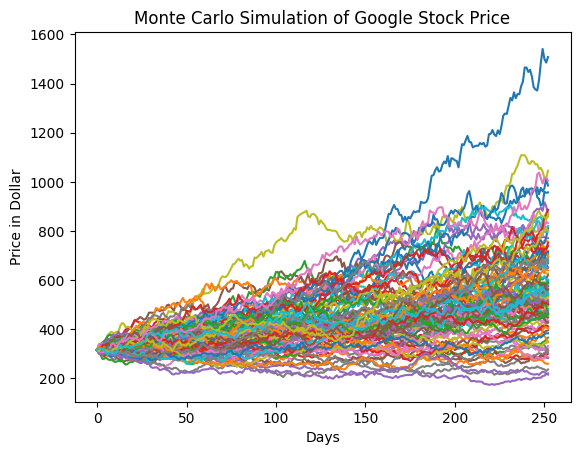

In [289]:
import matplotlib.pyplot as plt

plt.plot(S[:, :100])  # plot 50 sample paths
plt.title("Monte Carlo Simulation of Google Stock Price")
plt.xlabel("Days")
plt.ylabel("Price in Dollar")
plt.show()